In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon_cells_labelled.txt', delimiter='\t', header=None)
df.columns = ['review', 'label']

# Display the first few rows
df.head()


,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


# ***Data Preprocessing***

1. Lowercasing

In [2]:
df['review'] = df['review'].str.lower()


2. Tokenization

In [8]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
df['tokens'] = df['review'].apply(nltk.word_tokenize)

3. Stopword Removal

In [10]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


4. Lemmatization

In [11]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])


[nltk_data] Downloading package wordnet to /root/nltk_data...


# *Train-Test Split*

1. Join Tokens Back

In [12]:
df['processed_review'] = df['tokens'].apply(lambda x: ' '.join(x))


2. Split the Data

In [13]:
from sklearn.model_selection import train_test_split

X = df['processed_review']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ***Vectorization and Model Training***

1. Vectorization

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


2. Model Training (Train a Naive Bayes classifier)

In [15]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

# ***Model Evaluation***

Make Predictions and Evaluate

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_vec)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.79
[[67 26]
 [16 91]]
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        93
           1       0.78      0.85      0.81       107

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200



# *         1. TF-IDF Vectorization*

Replacig CountVectorizer with TfidfVectorizer

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7, ngram_range=(1, 2))  # Include bigrams
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_vec, y_train)
y_pred_log_reg = log_reg.predict(X_test_vec)
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg)}')

# SVM
svm = SVC()
svm.fit(X_train_vec, y_train)
y_pred_svm = svm.predict(X_test_vec)
print(f'SVM Accuracy: {accuracy_score(y_test, y_pred_svm)}')

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_vec, y_train)
y_pred_rf = rf.predict(X_test_vec)
print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)}')


Logistic Regression Accuracy: 0.755
SVM Accuracy: 0.775
Random Forest Accuracy: 0.735


# ***Hyperparameter Tuning***

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_search.fit(X_train_vec, y_train)
print(f'Best Parameters: {grid_search.best_params_}')


Best Parameters: {'C': 10, 'solver': 'liblinear'}


Refine preprocessing by removing special characters or applying stemming

In [22]:
import re  # Import the re module for regular expressions

def preprocess(text):
    # Remove special characters
    text = re.sub(r'\W', ' ', text)
    # Tokenize and stem
    tokens = nltk.word_tokenize(text)
    tokens = [stemmer.stem(token) for token in tokens if token not in stop_words]
    return ' '.join(tokens)

df['review'] = df['review'].apply(preprocess)



Cross-Validation (Use k-fold cross-validation for more robust model evaluation)

In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LogisticRegression(), X_train_vec, y_train, cv=5)
print(f'Cross-Validation Scores: {scores}')


Cross-Validation Scores: [0.725   0.7625  0.78125 0.71875 0.76875]


Additional Metrics (Evaluate using ROC-AUC and Precision-Recall curves)

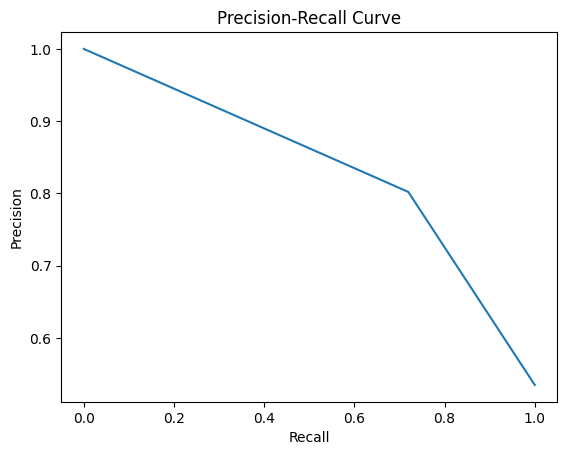

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Assuming y_test and y_pred_log_reg are already defined from your model predictions
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_log_reg)

# Plot Precision-Recall curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

